# Day 23 — Exercises: Classification

Complete the following exercises to practice the core concepts for Day 23.

**Topics covered:**
- Training and evaluating Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN)
- Visualizing classifier decision boundaries

## Exercise 1: Plotting Classifier Decision Boundaries

In this exercise, you will train Logistic Regression, Decision Tree, and KNN classifiers on a synthetic classification dataset and plot their decision boundaries to observe how they differ.

### Tasks:
1. Generate a synthetic 2D dataset using `make_moons`.
2. Scale/standardize the data.
3. Fit `LogisticRegression`, `DecisionTreeClassifier`, and `KNeighborsClassifier`.
4. Plot the decision boundaries of all three classifiers side-by-side.

C:\Users\Kavya\AppData\Local\Temp\ipykernel_6180\3528183522.py:48: UserWarning: You passed an edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test,
C:\Users\Kavya\AppData\Local\Temp\ipykernel_6180\3528183522.py:48: UserWarning: You passed an edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test,
C:\Users\Kavya\AppData\Local\Temp\ipykernel_6180\3528183522.py:48: UserWarning: You passed an edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test,


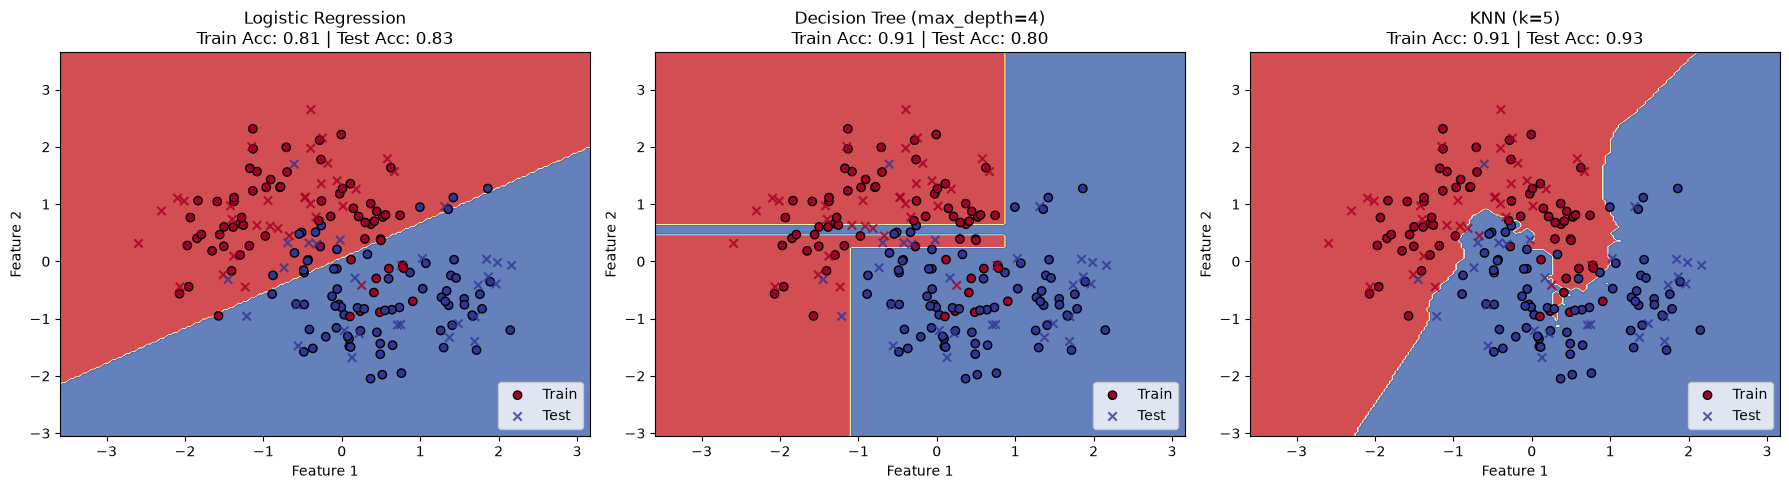

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Generate synthetic dataset
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

# 3. Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# 4. Fit and plot decision boundaries side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, classifiers.items()):
    # Fit model
    clf.fit(X_train_scaled, y_train)
    
    # Evaluate accuracy
    train_acc = clf.score(X_train_scaled, y_train)
    test_acc = clf.score(X_test_scaled, y_test)
    
    # Plot the decision boundary
    DecisionBoundaryDisplay.from_estimator(
        clf, X_scaled, response_method="predict",
        cmap=plt.cm.RdYlBu, alpha=0.8, ax=ax, grid_resolution=200
    )
    
    # Plot data points
    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
               cmap=plt.cm.RdYlBu, edgecolors='k', marker='o', label='Train')
    ax.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
               cmap=plt.cm.RdYlBu, edgecolors='k', marker='x', alpha=0.8, label='Test')
    
    ax.set_title(f"{name}\nTrain Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()